# Data -> generator input: source-safe split + loader

**Task:** produce canonical `train_sources` / `validation_sources` /
`test_sources` lists, reject TEST sources at the generator's door, and make
the generator obtain its image only through a loader function - never a
hardcoded filename.

**Key finding used here:** EMPS ships its own official `train.csv`/`test.csv`
(by image filename). We verified those are already DOI-safe - zero DOI
overlap between the two files. So instead of re-splitting from scratch, we
keep the official test set untouched and carve a validation set out of the
official train pool, split by DOI (source), never by individual image.


In [1]:
import sys, os
sys.path.append(os.path.join("..", "..", "src"))
from data.split import build_source_split

manifest = build_source_split(
    emps_dir=os.path.join("..", "..", "..", "AMAT", "amat4-week1", "emps"),
    out_path=os.path.join("..", "..", "configs", "experiments", "source_split_v1.json"),
    val_fraction=0.15,
    seed=0,
)

print(f"train:      {len(manifest['train_ids']):3d} images / {len(manifest['train_sources']):3d} sources")
print(f"validation: {len(manifest['validation_ids']):3d} images / {len(manifest['validation_sources']):3d} sources")
print(f"test:       {len(manifest['test_ids']):3d} images / {len(manifest['test_sources']):3d} sources")

assert not (set(manifest['train_sources']) & set(manifest['validation_sources']) & set(manifest['test_sources']))
print("No source appears in more than one split.")


train:      310 images / 210 sources
validation:  56 images /  37 sources
test:        99 images /  75 sources
No source appears in more than one split.


## Loader: the only door into the generator

In [2]:
from data.loader import load_generator_source, TEST_IDS, DEV_SOURCE_IDS

# Required deliverable pattern:
img, source_id = load_generator_source(DEV_SOURCE_IDS[0])
assert source_id not in TEST_IDS
print(f"loaded {source_id}, shape={img.shape}, source_id not in TEST_IDS: OK")


loaded 00655d9628, shape=(515, 512), source_id not in TEST_IDS: OK


In [3]:
# Rejection actually works - not just an assert we never trigger.
test_example = next(iter(TEST_IDS))
try:
    load_generator_source(test_example)
    raise SystemExit("BUG: a TEST source was NOT rejected")
except AssertionError as e:
    print(f"Correctly rejected: {e}")


Correctly rejected: Refused: '3f97a9e821' is a TEST source, not usable by the generator.


## Selected TRAIN images for generator development

Three source images selected for building/testing `generator_v0` in the next
notebook. Chosen only from the TRAIN split (never validation/test).

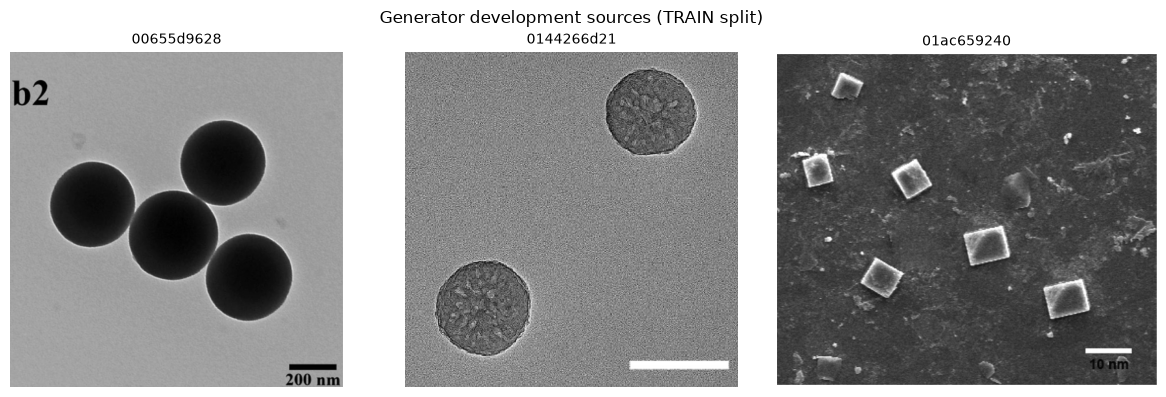

DEV_SOURCE_IDS: ['00655d9628', '0144266d21', '01ac659240']


In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, sid in zip(axes, DEV_SOURCE_IDS):
    img, source_id = load_generator_source(sid)
    ax.imshow(img, cmap="gray")
    ax.set_title(source_id, fontsize=10)
    ax.axis("off")
plt.suptitle("Generator development sources (TRAIN split)")
plt.tight_layout()
plt.show()

print("DEV_SOURCE_IDS:", DEV_SOURCE_IDS)


## Conclusion

- `configs/experiments/source_split_v1.json` is the canonical, immutable
  split manifest: 210 TRAIN sources (310 images), 37 VALIDATION sources (56
  images), 75 TEST sources (99 images) - carved by DOI, zero cross-split
  leakage, verified by assertion.
- `src/data/loader.py` is now the **only** path into the generator;
  `load_generator_source(source_id)` refuses any TEST id and returns
  `(img, source_id)`.
- Three TRAIN sources (`00655d9628`, `0144266d21`, `01ac659240`) are selected
  for `generator_v0` development in the next notebook.
